In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import train_test_split

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
# Applicazione di Machine Learning e Valutazione Modelli.
# Creo un solo dataframe (df) che conterrà il contenuto di entrmambi i file csv

DATASET_DIRECTORY ="../Data/"

df1 = pd.read_csv(os.path.join(DATASET_DIRECTORY, "Merged01.csv"))
df2 = pd.read_csv(os.path.join(DATASET_DIRECTORY, "Merged02.csv"))
df3 = pd.read_csv(os.path.join(DATASET_DIRECTORY, "Extra.csv"))

df = pd.concat([df1, df2, df3], axis=0, ignore_index=True)


<Axes: >

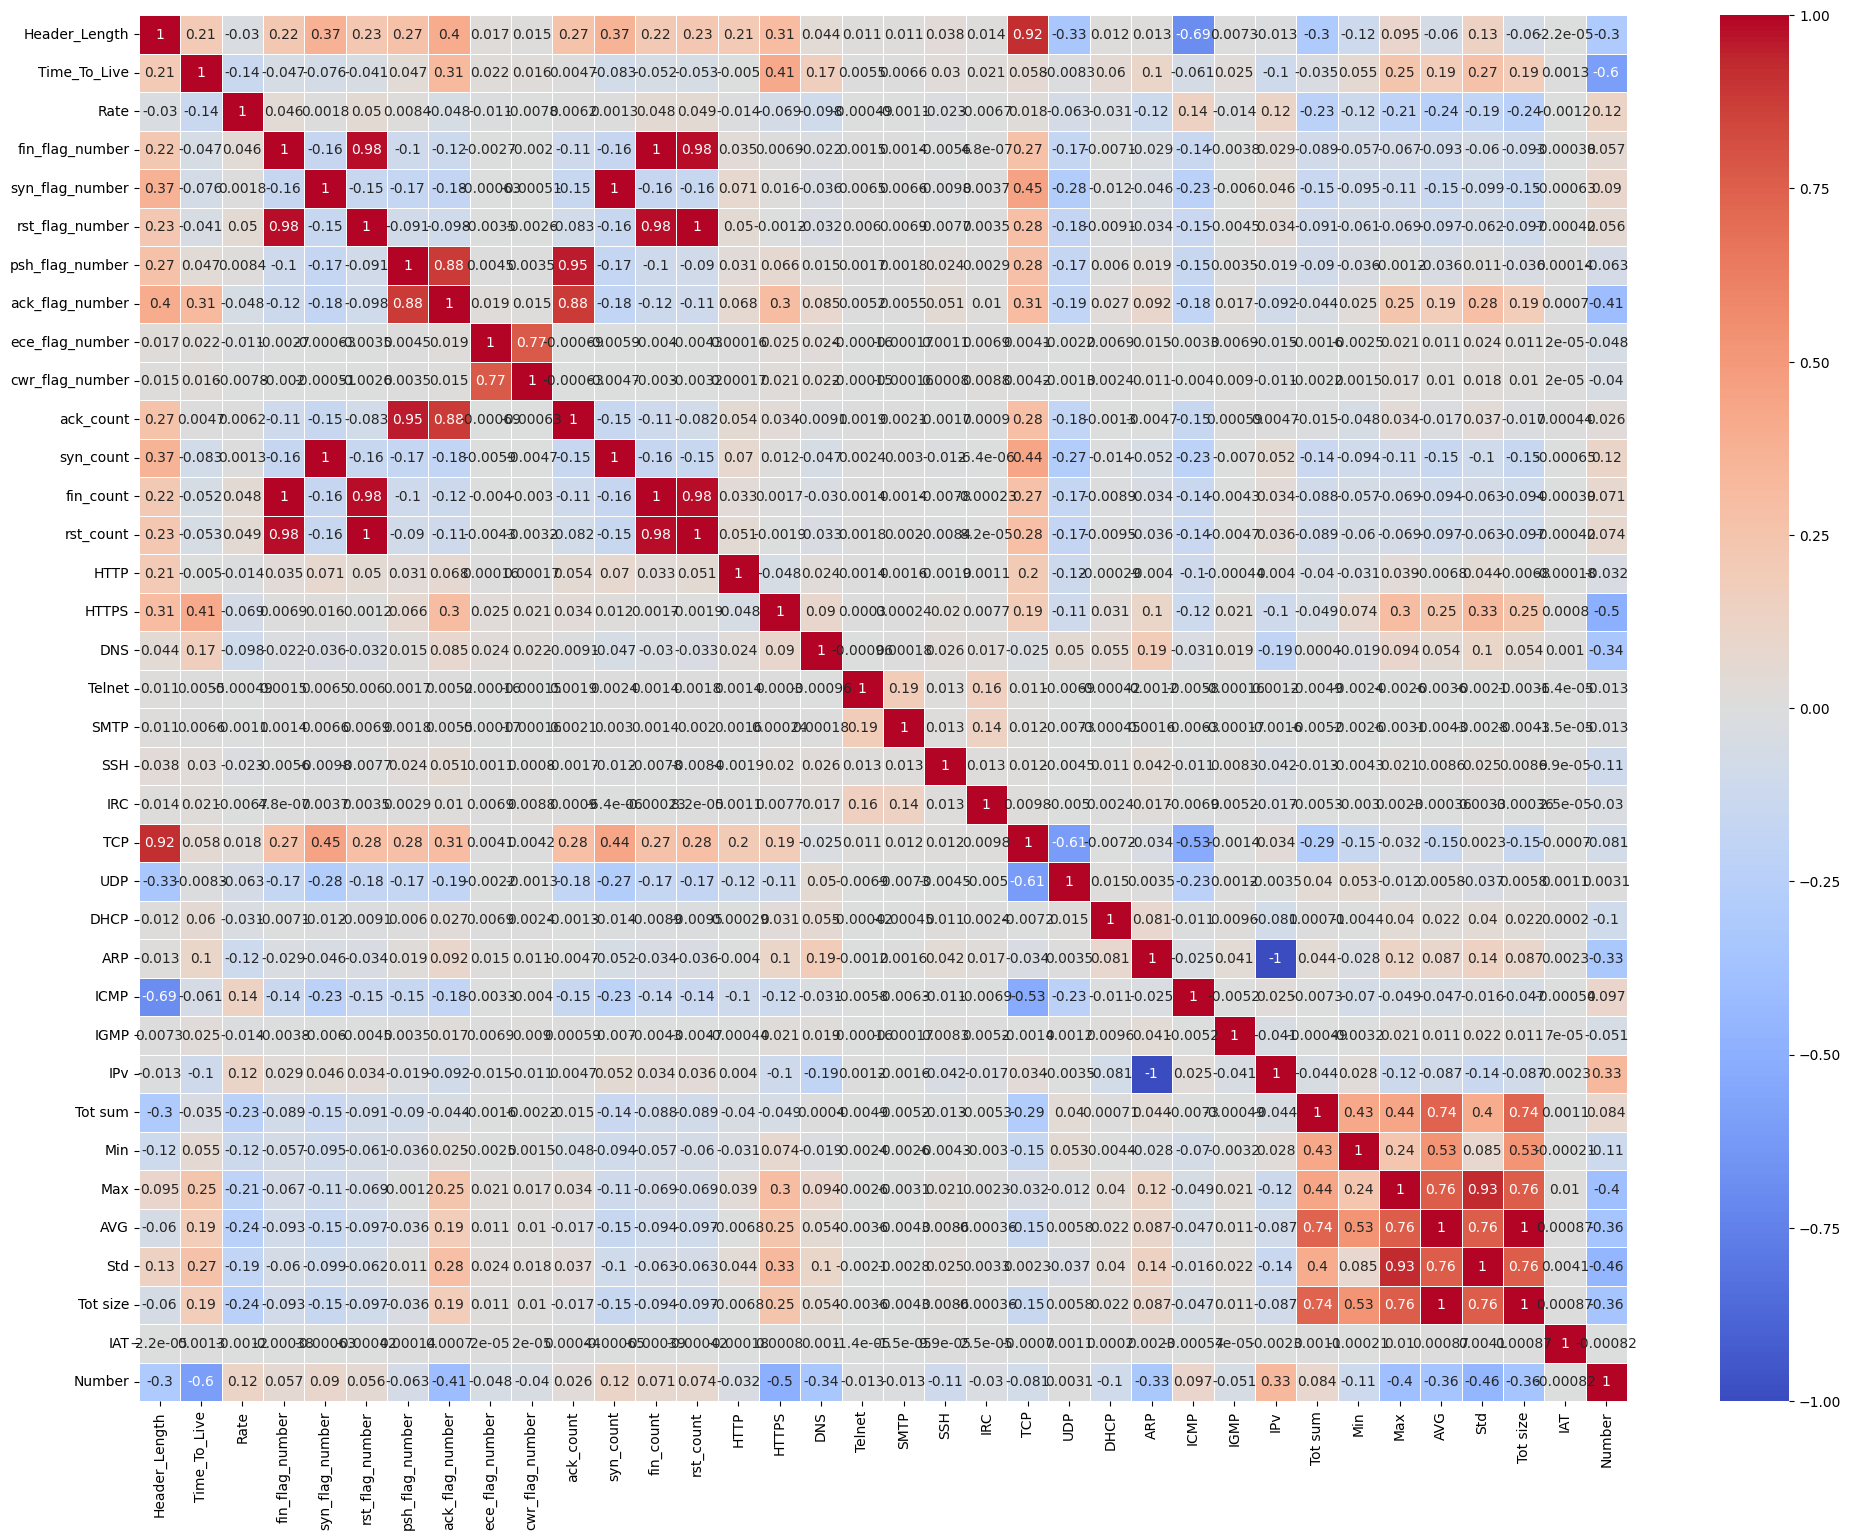

In [3]:
# Da X_colums ho tolto le colonne che dallo studio svolto nel file study.ipynb sono risultate rumore
# colonne tolte: Variance, LLC, Protocol Type, fin_count, syn_count, rst_count, ack_count e Tot Size
X_columns = [
    'Header_Length', 'Time_To_Live', 
    'Rate', 'fin_flag_number', 'syn_flag_number', 
    'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 
    'ece_flag_number', 'cwr_flag_number', 'ack_count', 
    'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 
    'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP',
    'ARP', 'ICMP', 'IGMP', 'IPv', 'Tot sum', 'Min', 'Max', 
    'AVG', 'Std', 'Tot size', 'IAT', 'Number'
]

# Effettuo un encoding della colonna target in modo da trasformare ogni tipo di attacco in un valore numerico
#faccio una mappatura a mano per essere più preciso

mappatura_label = {
    'BENIGN': 0,
    'DDOS-PSHACK_FLOOD': 1,
    'MIRAI-GREIP_FLOOD': 2,
    'DOS-UDP_FLOOD': 3,
    'DNS_SPOOFING': 4,
    'DDOS-ICMP_FLOOD': 5,
    'DDOS-TCP_FLOOD': 6,
    'DDOS-SYN_FLOOD': 7,
    'DDOS-UDP_FLOOD': 8,
    'MITM-ARPSPOOFING': 9,
    'DDOS-SYNONYMOUSIP_FLOOD': 10,
    'DOS-TCP_FLOOD': 11,
    'VULNERABILITYSCAN': 12,
    'DOS-SYN_FLOOD': 13,
    'DDOS-RSTFINFLOOD': 14,
    'DDOS-SLOWLORIS': 15,
    'DDOS-ICMP_FRAGMENTATION': 16,
    'MIRAI-GREETH_FLOOD': 17,
    'RECON-HOSTDISCOVERY': 18,
    'MIRAI-UDPPLAIN': 19,
    'RECON-PORTSCAN': 20,
    'DDOS-ACK_FRAGMENTATION': 21,
    'DDOS-UDP_FRAGMENTATION': 22,
    'RECON-OSSCAN': 23,
    'BACKDOOR_MALWARE': 24,
    'DOS-HTTP_FLOOD': 25,
    'XSS': 26,
    'DDOS-HTTP_FLOOD': 27,
    'BROWSERHIJACKING': 28,
    'SQLINJECTION': 29,
    'DICTIONARYBRUTEFORCE': 30,
    'COMMANDINJECTION': 31,
    'RECON-PINGSWEEP': 32,
    'UPLOADING_ATTACK': 33
}
df['Label'] = df['Label'].map(mappatura_label)
y_column = 'Label'

# rimuovo in oltre le righe del dataset che contengono valori inf o nulli nelle colonne : STD e Rete
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

X = df[X_columns]
y = df[y_column]


corr_matrix_DF1 = df[X_columns].corr()
plt.figure(figsize=(24, 18))
sns.heatmap(corr_matrix_DF1, annot=True, cmap='coolwarm', linewidths=0.5,vmin=-1, vmax=1)


In [4]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error

#faccio un primo test con un 70%-30%, poi provo altre percentuali, sarà tutto salvato in delle note 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"MSE: {mse*100:.2f}")
print(f"RMSE: {rmse*100:.2f}")

# --- RISULTATI REGRESSIONE LINEARE ---
# Test con 70%-30%: MSE: 948.66 | RMSE: 308.00
# Test con 80%-20%: MSE: 946.83 | RMSE: 307.71
# Test con 60%-40%: MSE: 950.21 | RMSE: 308.25

# OSSERVAZIONE:
# Le prestazioni del modello risultano scadenti, penso che il motivo sia un errata scelta del modello di ML
# la Regressione Lineare è progettata per stimare variabili continue, il nostro target, al contrario, è una variabile nominale. 
# I valori numerici assegnati agli attacchi fungono da semplici etichette e non possiedono  alcun significato matematico o ordinale.
# Concludo dicendo che, l'approccio regressivo è inefficace. Nelle sezioni successive il problema verrà affrontato utilizzando modelli differenti.

MSE: 1021.21
RMSE: 319.56


Accuracy: 0.74
Precision: 0.76
Recall: 0.74
F1-Score: 0.70


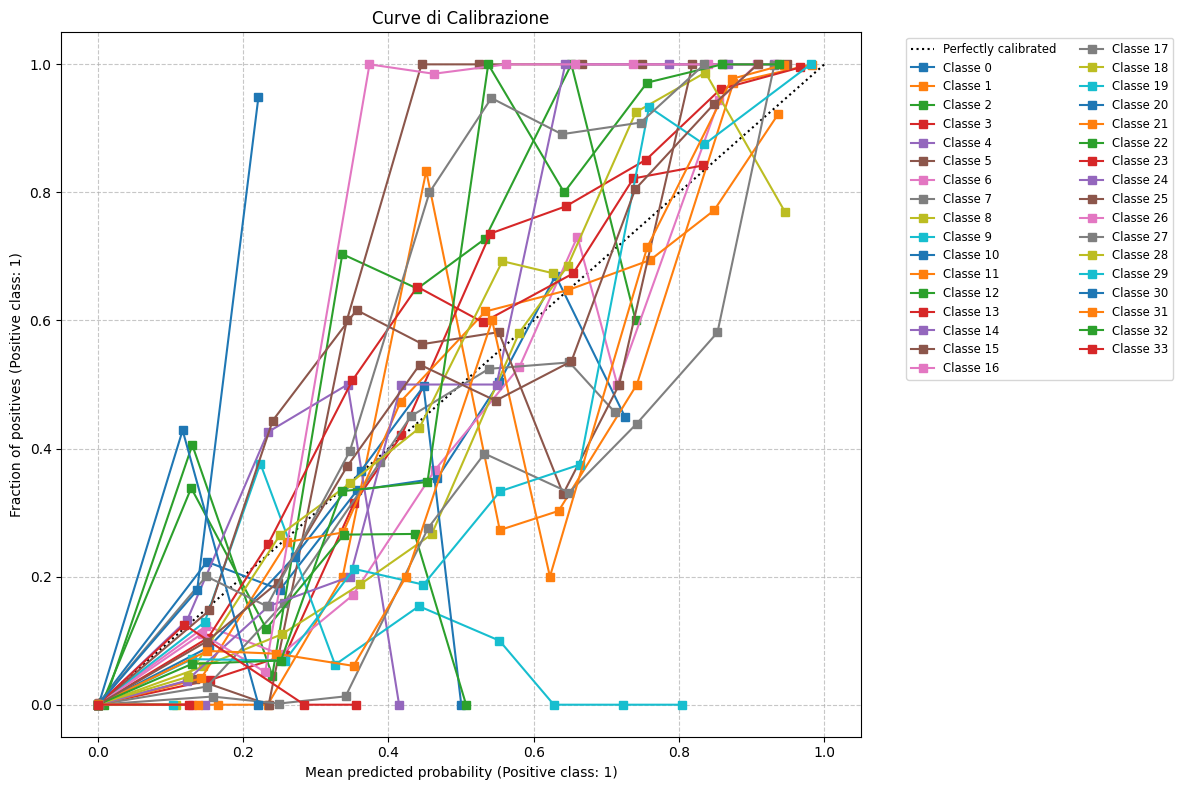


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.48      0.98      0.64      6843
           1       1.00      1.00      1.00     25537
           2       0.97      0.42      0.58      4614
           3       0.93      0.29      0.44     20586
           4       0.82      0.01      0.02      1129
           5       1.00      1.00      1.00     44649
           6       0.63      0.99      0.77     27900
           7       0.43      0.67      0.52     25256
           8       0.69      0.99      0.81     33601
           9       0.13      0.01      0.02      1918
          10       0.50      0.44      0.47     22413
          11       0.65      0.04      0.08     16624
          12       0.26      0.01      0.01      2363
          13       0.60      0.05      0.09     12569
          14       1.00      1.00      1.00     25116
          15       0.50      0.54      0.52       354
          16       0.95      0.98      0.96      2802
    

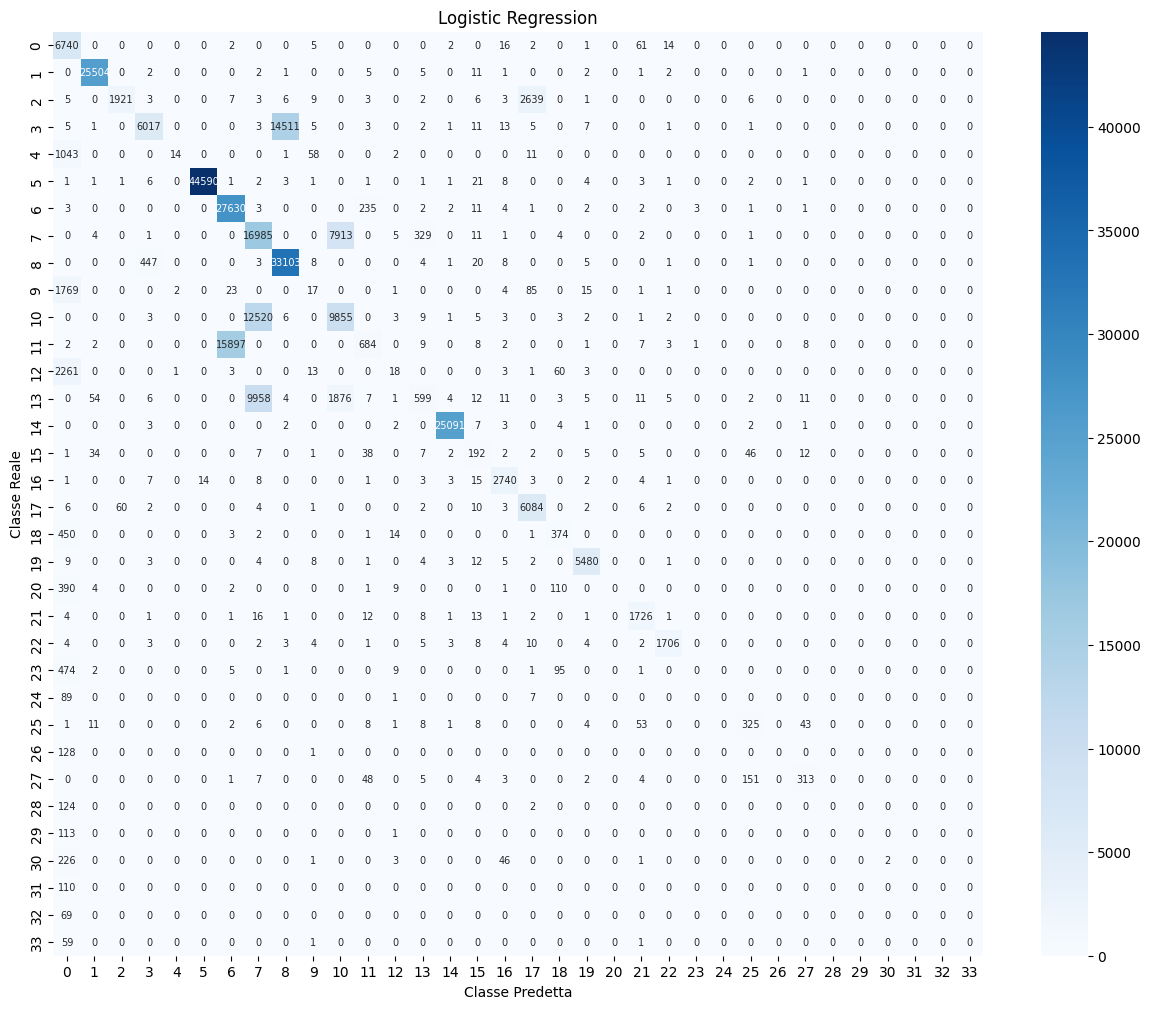

In [5]:

#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

#from sklearn.preprocessing import RobustScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

# -- Oversampling e Undersampling -- 
MAX_RIGHE = 15000
MIN_RIGHE = 3000

#Funzioni per il calcolo dei conteggi, necessarie per utilizzare il calibratore. (se non lo mettessimo quandoil calibrtore divide i dati in 3 i smapler vanno in crash)
def calcola_under(y_al_momento):
    conteggi = Counter(y_al_momento)
    return {clas: min(n, MAX_RIGHE) for clas, n in conteggi.items()}

def calcola_over(y_al_momento):
    conteggi = Counter(y_al_momento)
    return {clas: max(n, MIN_RIGHE) for clas, n in conteggi.items()}

undersampler = RandomUnderSampler(sampling_strategy=calcola_under, random_state=42)
oversampler  = SMOTE(sampling_strategy=calcola_over, random_state=42, k_neighbors=3)

lr_model = LogisticRegression(
    solver='lbfgs',                        
    max_iter=500,
    C=1.0,                      # Per evitare overfitting
    #class_weight='balanced',
    #n_jobs=-1,                 
    random_state=42,
    tol=1e-3                    # più tolleranza per risparmiare tempo
)

scaler = StandardScaler()
pipeline_lr = Pipeline(steps=[
    ('Normalizzazione', scaler),        # lo scaler viene fatto direttamente nella pipeline
    ('Riduci_Maggioranza', undersampler), 
    ('Aumenta_Minoranza', oversampler),   
    ('Classificatore_LR', lr_model)       
])

calibrated_lr = CalibratedClassifierCV(pipeline_lr, method='isotonic', cv=3)

calibrated_lr.fit(X_train,y_train)
y_pred_log = calibrated_lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_log, average='weighted')
f1 = f1_score(y_test, y_pred_log, average='weighted')
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# -- GRAFICI --
y_prob = calibrated_lr.predict_proba(X_test)

plt.figure(figsize=(12, 8))
asse_grafico = plt.gca()                #Seleziona l'asse, necessario per fare il grafico

for classe in range(34):
    y_binario = (y_test == classe).astype(int)
    prob_classe = y_prob[:, classe]
    
    CalibrationDisplay.from_predictions(
        y_binario,                   
        prob_classe,               
        n_bins=10,                        # Divide il grafico in 10 "tappe" da 0 a 100%
        name=f"Classe {classe}",          
        ax=asse_grafico                   # Diciamo di disegnare tutto sullo stesso grafico
    )

plt.title("Curve di Calibrazione")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.tight_layout() # Sistema i margini
plt.show()

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_log, zero_division=0))

print("\nCONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True,fmt='g', annot_kws={"size":7}, cmap='Blues',cbar=True)
plt.title('Logistic Regression')
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.show()

#TEST
# Prova con solver = saga e max_iter = 100, Risultati: Accuracy: 0.68, Precision: 0.73, Recall: 0.68, F1-Score: 0.68 T_esec 5:03 -- risultati dovuti al max_iter troppo basso, ma aumentandolo si allungherebbero di troppo i tempi di esecuzione
# Prova con solver = lbfgs e max_iter = 500, Risutlati: Accuracy: 0.72, Precision: 0.75, Recall: 0.72, F1-Score: 0.71 T_esec : 5:26 -- risultati migliori grazie all'aumento delle iterazioni ma ancora tempi troppo lunghi per i risultati ottenuti
# Prova con solver = lbfgs e max_iter = 500 ma rimuovendo C=1.0, Risutlati: Accuracy: 0.72, Precision: 0.75, Recall: 0.72, F1-Score: 0.71 T_esec : 5:28 -- risultati identici, non era la regolarizzazione a dare problemi
# Prova con solver = lbfgs e max_iter = 500 ma utilizzando uno scaler dviverso (RobustScaler): Accuracy: 0.53, Precision: 0.57, Recall: 0.53, F1-Score: 0.51 -- Pessimo

#OSSERVAZIONI
# La logistic regression non raggiunge i livelli di accuratezza desiderati e soprattutto impega molto più tempo di altri modelli che arrivano a risultati migliori in meno tempo.
# Aumentando il numero di iterazioni si potrebbe puntare ad ottenere risultati migliori ma a netto discapito delle tempistiche che sono gia eccessivamente lunghe.

#TEST 2 
# Prova con solver = lbfgs e max_iter = 500 e aggiunta calibrazione con CalibratedClassifierCV Risultati: Accuracy: 0.73, Precision: 0.74, Recall: 0.73, F1-Score: 0.69 T_Esec: 9:54 -- Noto che con la calibrazione l'accuratezza è aumentata ma è diminuito drasticamente l'F1_score. Inoltre sono aumentati anche i tempi di esecuzione
# L'analisi del grafico mostra una grave insabilità, in alucni casi il modello sottostima e in altri sovrastima. Dimostra che per alcune classi il nostro modello è molto performante ma per altre prorpio no. Unica nota positiva sembra overperformare quando la classe da indovinare è benigna. 

#Test 3
# Aggiunto Oversampling e Undersampling Risultati: Accuracy: 0.74 Precision: 0.74 Recall: 0.74 F1-Score: 0.70 T_esec: 2:13 (MAX_RIGHE = 15000, MIN_RIGHE = 3000)
# Applicando Oversampling e Undersampling l'accuratezza totale è aumentata di una percentuale ma la macroF1 è ancora molto bassa: 0.38

# Dopo ver riaggiunto tre colonne: Header Lenght, psh_flag_number e rst_flag_number Risultati: Accuracy: 0.74 Precision: 0.76 Recall: 0.74 F1-Score: 0.70 macro avg: 0.41 T_esec: 1:10

#Dopo aver aggiunto CSV extra e stratify=y nel traintest: Risultati: 

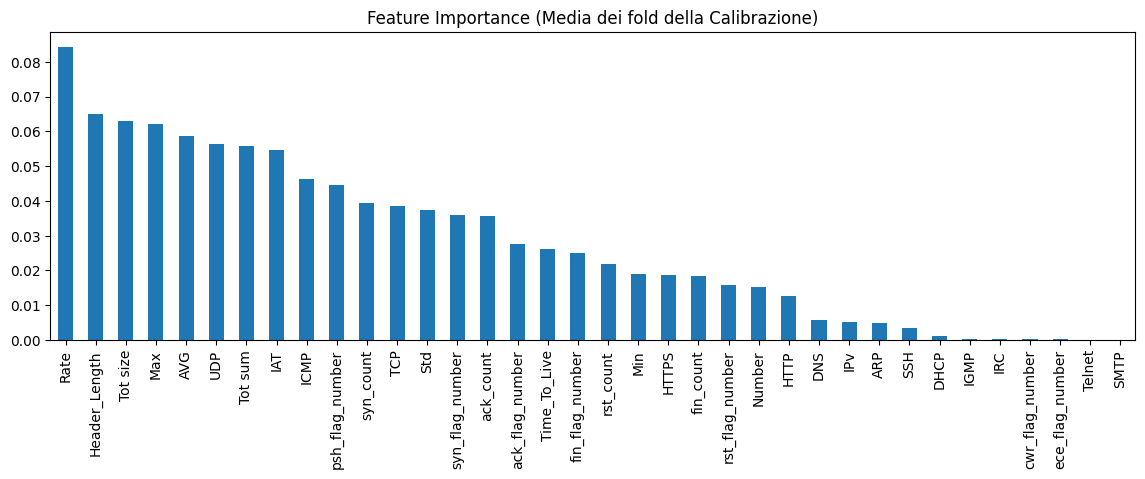

Accuracy: 0.78
Precision: 0.78
Recall: 0.78
F1-Score: 0.76


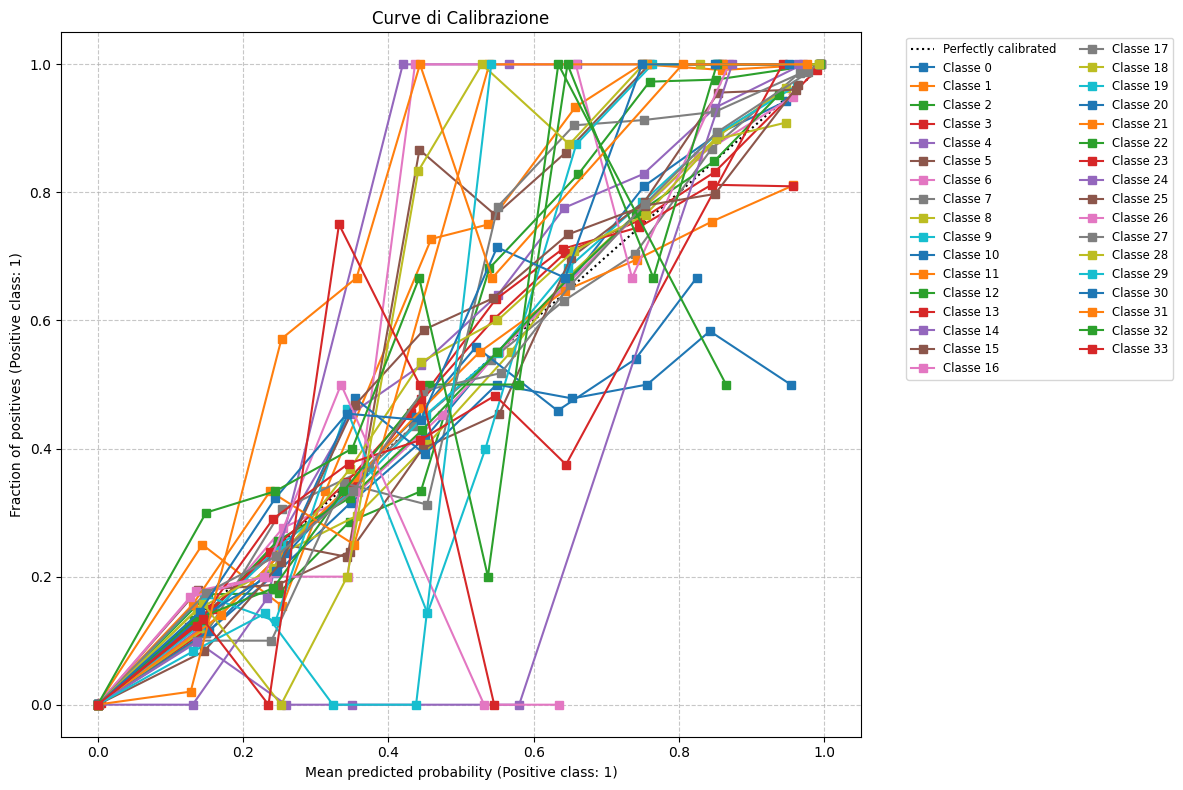


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.75      0.91      0.82      6843
           1       1.00      1.00      1.00     25537
           2       1.00      1.00      1.00      4614
           3       0.81      0.41      0.55     20586
           4       0.78      0.59      0.67      1129
           5       1.00      1.00      1.00     44649
           6       0.67      0.89      0.76     27900
           7       0.48      0.43      0.46     25256
           8       0.72      0.94      0.82     33601
           9       0.76      0.76      0.76      1918
          10       0.47      0.69      0.56     22413
          11       0.59      0.26      0.36     16624
          12       0.53      0.63      0.58      2363
          13       0.60      0.21      0.31     12569
          14       1.00      1.00      1.00     25116
          15       0.73      0.92      0.81       354
          16       0.99      0.98      0.99      2802
    

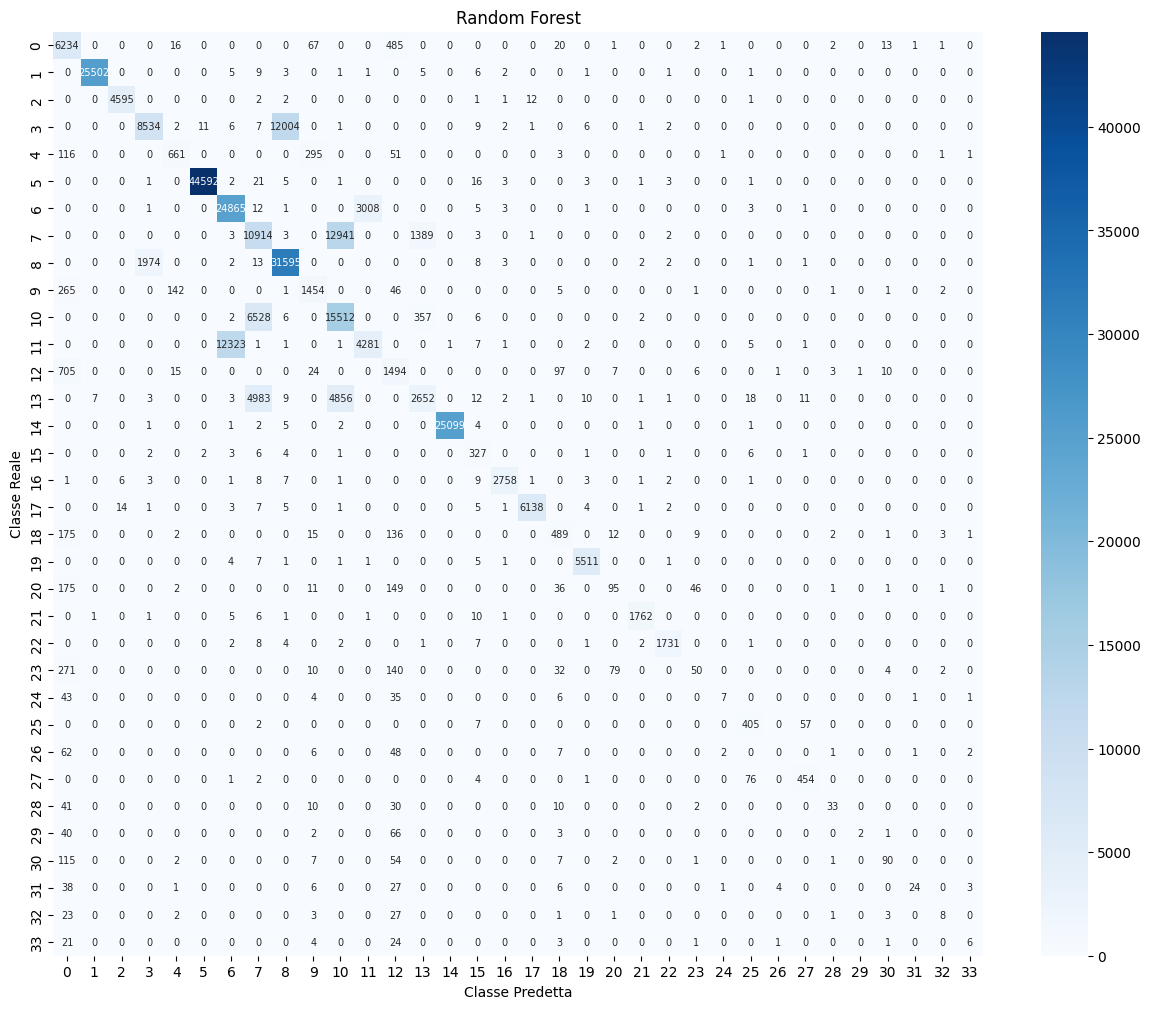

In [6]:

# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)        #Stratify serve per bilanciare il train test

# -- Oversampling e Undersampling -- 
MAX_RIGHE = 15000
MIN_RIGHE = 3000

#Funzioni per il calcolo dei conteggi, necessarie per utilizzare il calibratore. (se non lo mettessimo quandoil calibrtore divide i dati in 3 i smapler vanno in crash)
def calcola_under(y_al_momento):
    conteggi = Counter(y_al_momento)
    return {clas: min(n, MAX_RIGHE) for clas, n in conteggi.items()}

def calcola_over(y_al_momento):
    conteggi = Counter(y_al_momento)
    return {clas: max(n, MIN_RIGHE) for clas, n in conteggi.items()}

undersampler = RandomUnderSampler(sampling_strategy=calcola_under, random_state=42)
oversampler  = SMOTE(sampling_strategy=calcola_over, random_state=42, k_neighbors=3)

rf_model = RandomForestClassifier(
    n_estimators=100, 
    #max_depth=20,                          # Aggiungo un max_depth così da poter non far crushare la ram
    #class_weight='balanced',                # Necessario per bilanciare gli output a causa dello sbilanciamento del dataset
    random_state=42, 
    n_jobs=-1
)

pipeline_rf = Pipeline(steps=[
    ('Riduci_Maggioranza', undersampler),
    ('Aumenta_Minoranza', oversampler),
    ('Classificatore_RF', rf_model)
])

calibrated_rf = CalibratedClassifierCV(pipeline_rf, method='isotonic', cv=3)
calibrated_rf.fit(X_train, y_train)

#-- Feature Importance --
all_importances = []
for calibrated_classifier in calibrated_rf.calibrated_classifiers_:
    model = calibrated_classifier.estimator.named_steps['Classificatore_RF']
    all_importances.append(model.feature_importances_)

avg_importances = np.mean(all_importances, axis=0)
importances = pd.Series(avg_importances, index=X_columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(14,4))
plt.title("Feature Importance (Media dei fold della Calibrazione)")
plt.show()

# -- Valori Output --

y_pred_rf = calibrated_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')                # Il fatto che questo valore sia simile all'accuratezza fa intendere che il modello non va in overfiitng ma indovina anche i valori più rari
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# -- GRAFICI --
y_prob = calibrated_rf.predict_proba(X_test)

plt.figure(figsize=(12, 8))
asse_grafico = plt.gca()

for classe in range(34):
    y_binario = (y_test == classe).astype(int)
    prob_classe = y_prob[:, classe]
    
    CalibrationDisplay.from_predictions(
        y_binario,                   
        prob_classe,               
        n_bins=10,                        
        name=f"Classe {classe}",          
        ax=asse_grafico                  
    )

plt.title("Curve di Calibrazione")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.tight_layout() 
plt.show()

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("\nCONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True,fmt='g', annot_kws={"size":7}, cmap='Blues',cbar=True)
plt.title('Random Forest')
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.show()

# TEST
# Prova con n_estimators = 100 e test/train di 70%30%, Risultati: Accuracy: 0.78, Precision: 0.78, Recall: 0.77, F1-Score: 0.78 
# Prova con n_estimators = 100, test/train di 70%30% e max_depth:20, Risultati: Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 T_Esec: 1:24
# Prova con n_estimators = 100, test/train di 80%20% e max_depth:20, Risultati: Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 T_Esec: 1:47
# Prova con n_estimators = 200, test/train di 70%30% e max_depth:20, Risultati: Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 T_Esec: 2:52
# Prova con n_estimators = 200, test/train di 80%20% e max_depth:20, Risultati: Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 T_Esec: 3:10

# OSSERVAZIONE:
# Nel primo test senza limitazioni di profondità questo modello ha raggiunto le prestazioni massime (78%) ma purtroppo nei successivi test non mettere limitazioni
# ha portato al crash della RAM quindi per garantire stabilità ho dovuto aggiungerla peggiorando le prestazioni.
# La modifica del numero di alberi (aumentando il numero da 100 a 200) non ha portato alcun tipo di milgioria dal punto di vista della precisione ma ha solo allungato i tempi di esecuzione
# la mia conclusione finale è che il random forest è un modello di base che produce di buoni risultati ma i limiti di memoria legati alla creazione di 
# alberi paralleli e la difficoltà nell'estrarre pattern più complessi rende questo modello non non ancora sufficientemente accurato.

#TEST 2 
# Aggiunta calibrazione con CalibratedClassifierCV Risultati:Accuracy: 0.78, Precision: 0.79, Recall: 0.78, F1-Score: 0.77 T_Esec: 2:43 -- Grazie alla calibrazione si nota un miglioramento delle statistche
# L'applicazione della calibrazione ha prodotto risultati eccellenti per l'affidabilità dei punteggi. dal grafico si vede chiaramente che il modello si avvicina molto di più alla perfezione (linea diagonale).
# Nonstante questo ancora alcune classi vengono sbagliate, soprattutto nella fase iniziale del lavoro.

#Test 3
# Aggiunto Oversampling e Undersampling Risultati: Accuracy: 0.78 Precision: 0.78 Recall: 0.78 F1-Score: 0.76 T_esec: 2:35 (MAX_RIGHE = 15000, MIN_RIGHE = 3000)
# Applicando Oversampling e Undersampling l'accuratezza totale non cambia ma il macroF1 aumenta e passa da 0.56 a 0.60 con ancora alcune classi ferme allo 0%

# Dopo ver riaggiunto tre colonne: Header Lenght, psh_flag_number e rst_flag_number Risultati: Accuracy: 0.78 Precision: 0.78 Recall: 0.78 F1-Score: 0.76 macro avg: 0.60 T_esec: 0:58

Accuracy: 0.78
Precision: 0.79
Recall: 0.78
F1-Score: 0.77


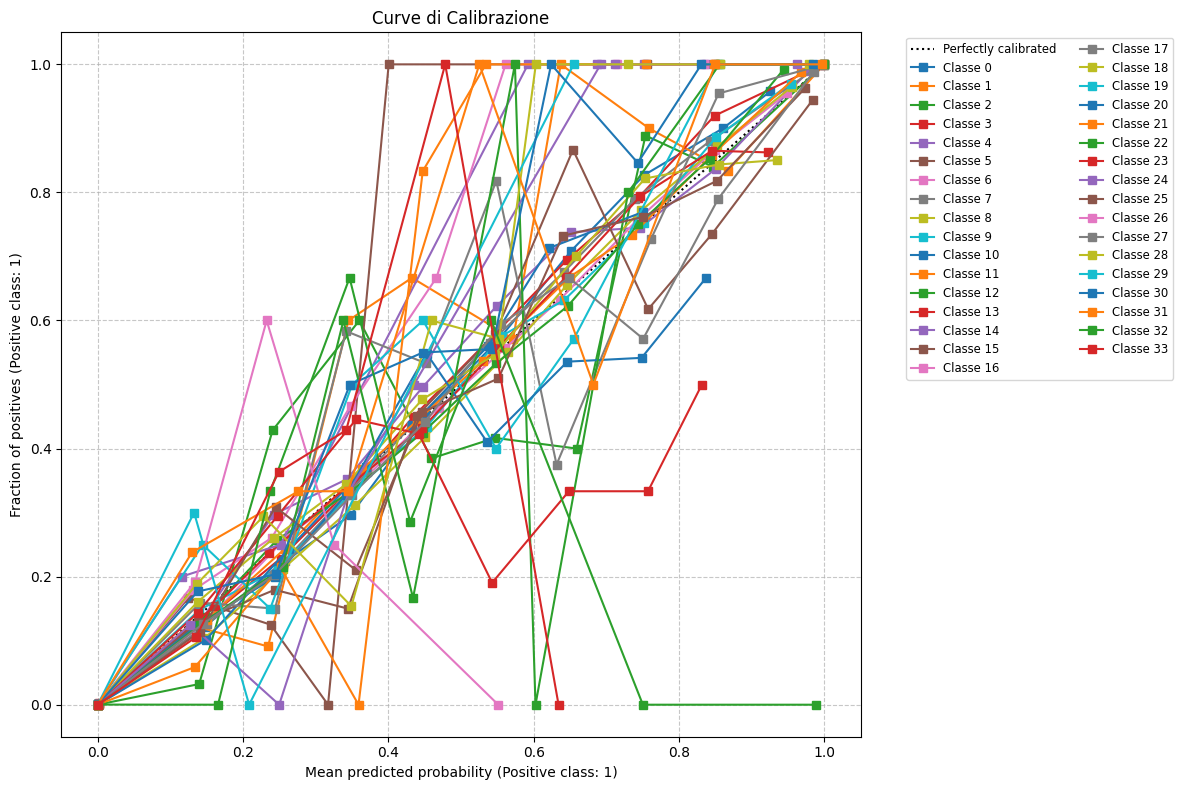


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.76      0.92      0.83      6843
           1       1.00      1.00      1.00     25537
           2       0.99      1.00      1.00      4614
           3       0.80      0.45      0.58     20586
           4       0.76      0.60      0.67      1129
           5       1.00      1.00      1.00     44649
           6       0.68      0.87      0.76     27900
           7       0.51      0.41      0.46     25256
           8       0.74      0.93      0.82     33601
           9       0.76      0.77      0.76      1918
          10       0.47      0.72      0.57     22413
          11       0.59      0.32      0.42     16624
          12       0.55      0.64      0.59      2363
          13       0.63      0.27      0.37     12569
          14       1.00      1.00      1.00     25116
          15       0.77      0.94      0.85       354
          16       0.99      0.99      0.99      2802
    

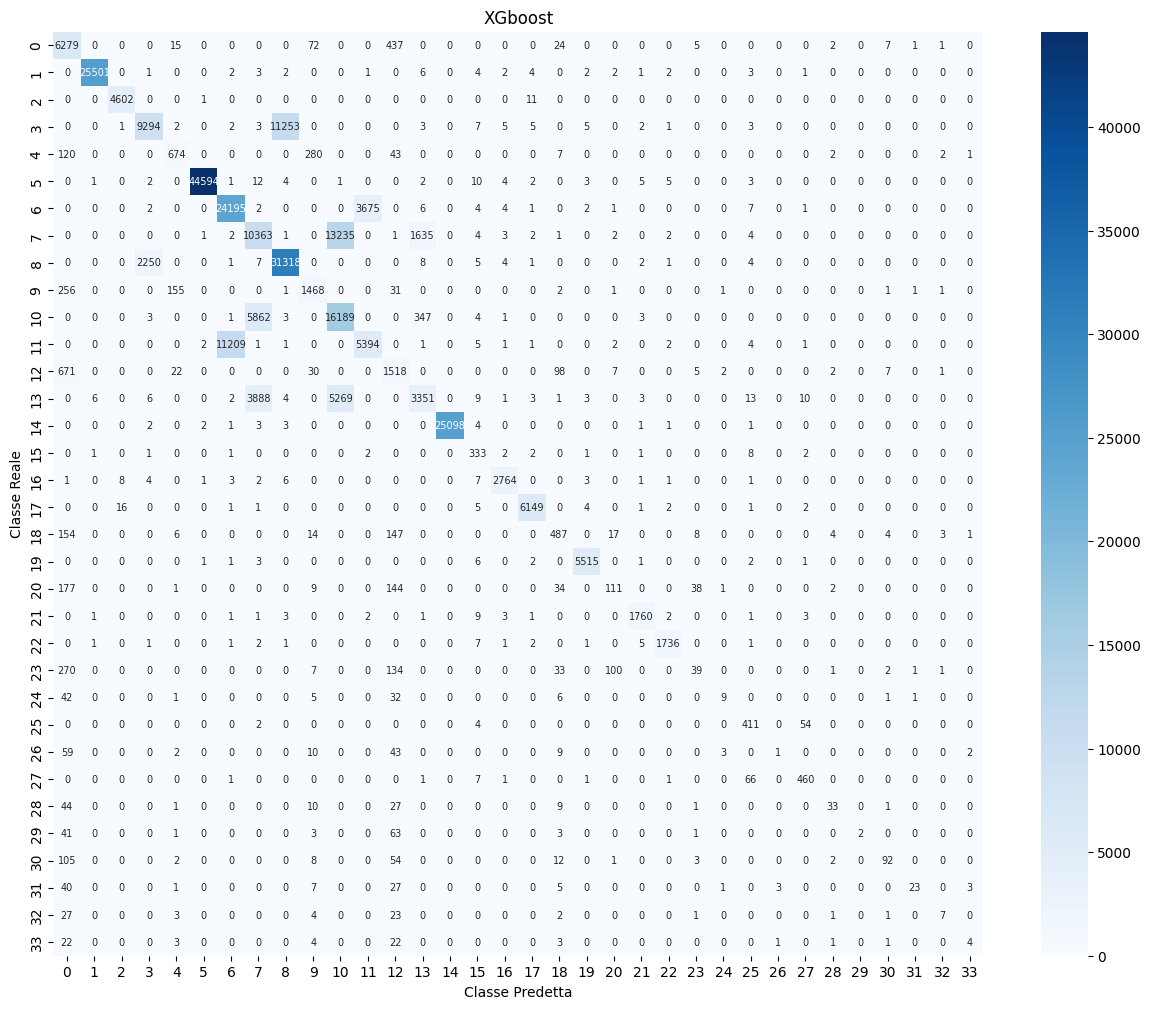

In [7]:

# XGboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

# -- Oversampling e Undersampling -- 
MAX_RIGHE = 15000
MIN_RIGHE = 3000

#Funzioni per il calcolo dei conteggi, necessarie per utilizzare il calibratore. (se non lo mettessimo quandoil calibrtore divide i dati in 3 i smapler vanno in crash)
def calcola_under(y_al_momento):
    conteggi = Counter(y_al_momento)
    return {clas: min(n, MAX_RIGHE) for clas, n in conteggi.items()}

def calcola_over(y_al_momento):
    conteggi = Counter(y_al_momento)
    return {clas: max(n, MIN_RIGHE) for clas, n in conteggi.items()}

undersampler = RandomUnderSampler(sampling_strategy=calcola_under, random_state=42)
oversampler  = SMOTE(sampling_strategy=calcola_over, random_state=42, k_neighbors=3)


# Calcolo e assegno pesi differenti a seconda della rarità delle classi, questo sempre dovuto allo sbilanciamento del dataset
# weight = compute_sample_weight(class_weight='balanced', y=y_train)                Non necessario con il sampler


xgb_model = XGBClassifier(
    n_estimators=150,          
    max_depth=8,               # provo una profondità bassa suggerita da Xgboost
    learning_rate=0.2,         # Tasso di apprendimento 
    subsample=0.6,             # + Velocità : Usa solo il 60% delle righe per ogni albero
    colsample_bytree=0.6,      # + Velocità : Usa solo il 60% delle colonne per ogni albero
    tree_method='hist',        # Utilizzo un motodo ad istogramma per ridurre i tempi
    #eval_metric='mlogloss',    # Indica quale formula matematica utilizzare per capire se sta migliorando o peggiorando durante la creazione degli alberi. essendo il target multiclasse uso mlogloss
    #early_stopping_rounds=10,  # Se per X alberi di fila non migliora, si ferma.
    n_jobs=-1,                 # Usa tutti i core del processore
    random_state=42                   
)

pipeline_xgb = Pipeline(steps=[
    ('Riduci_Maggioranza', undersampler),
    ('Aumenta_Minoranza', oversampler),
    ('Classificatore_XGB', xgb_model)
])

calibrated_xgb = CalibratedClassifierCV(pipeline_xgb, method='isotonic', cv=3)

# xgb_model.fit(
    #X_train, y_train, 
    #sample_weight=weight,
    #eval_set=[(X_test, y_test)],       # li uso per poter vedere le prestazioni
    #verbose=10                         # stampa i progressi ogni 50 alberi
#)

calibrated_xgb.fit(
    X_train,
    y_train, 
    #sample_weight=weight           #anche questo rimosso dopo aver aggiunto i sampler (non più necessario)
)

#-- Feature Importance --
# all_importances = []
# for calibrated_classifier in calibrated_xgb.calibrated_classifiers_:
#     model = calibrated_classifier.estimator.named_steps['Classificatore_XGB']
#     all_importances.append(model.feature_importances_)

# avg_importances = np.mean(all_importances, axis=0)
# importances = pd.Series(avg_importances, index=X_columns)
# importances.sort_values(ascending=False).plot(kind='bar', figsize=(14,4))
# plt.title("Feature Importance (Media dei fold della Calibrazione)")
# plt.show()

#--Predizione Valori
y_pred_xgb = calibrated_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"Accuracy: {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall: {recall_xgb:.2f}")
print(f"F1-Score: {f1_xgb:.2f}")

# -- GRAFICO --
y_prob = calibrated_xgb.predict_proba(X_test)
plt.figure(figsize=(12, 8))
asse_grafico = plt.gca()

for classe in range(34):
    y_binario = (y_test == classe).astype(int)
    prob_classe = y_prob[:, classe]
    
    CalibrationDisplay.from_predictions(
        y_binario,                   
        prob_classe,               
        n_bins=10,                        
        name=f"Classe {classe}",          
        ax=asse_grafico                   
    )

plt.title("Curve di Calibrazione")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.tight_layout() 
plt.show()

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

print("\nCONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True,fmt='g', annot_kws={"size":7}, cmap='Blues',cbar=True)
plt.title('XGboost')
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.show()

# TEST
# Prova con n_estimators = 100 e test/train di 80%20% e learning_rate=0.1, Risultati: Accuracy: 0.74, Precision: 0.78, Recall: 0.74, F1-Score: 0.74 T_Esec: 3:37
# Prova con n_estimators = 100 e test/train di 80%20% e learning_rate=0.2, Risultati: Accuracy: 0.75, Precision: 0.78, Recall: 0.75, F1-Score: 0.75 T_Esec: 3:57
# Prova con n_estimators = 100 e test/train di 80%20% e learning_rate=0.5, Risultati: Accuracy: 0.74, Precision: 0.77, Recall: 0.74, F1-Score: 0.74 T_Esec: :49 -- In questo test è scattato l'early-stop a 24 giri
# Prova con n_estimators = 100 e test/train di 80%20% e learning_rate=0.5, Risultati: Accuracy: 0.74, Precision: 0.77, Recall: 0.74, F1-Score: 0.74 T_Esec: 1:29 -- in questo ho aumentato l'early-stop da 10 a 20

# Prova con n_estimators = 300 e test/train di 80%20% e learning_rate=0.2, Risultati: Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 T_Esec 10:00 -- Noto che dal 100 giro in poi il miglioramento è minimo

# Prova con n_estimators = 150 e test/train di 80%20%, learning_rate=0.2 e max_depth=8, Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.76 -- Modifico il max_depth da 4 a 8, l'accuratezza è aumentata ma non notevolemnte
# Prova con n_estimators = 150 e test/train di 80%20%, learning_rate=0.2 e max_depth=16, Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.76 T_Esec: 3:20 --Modifico il max_depth da 8 a 16, nessun miglioramento

# Prova con n_estimators = 150 e test/train di 80%20%, learning_rate=0.2 e max_depth=8, Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.76 T_Esec: 6,16 -- Dopo aver rimosso subsample e colsample_bytree. nessun miglioramento, solo aumento di tempo di esecuzione

# OSSERVAZIONI
# Nonostante i vari test fatti il modello raggiunge uno stallo di accuratezza al 77%, L'uso di subsample=0.6 e colsample_bytree=0.6 ha ridotto notevolmente i tempi nonostante non abbia influito sull'efficacia del modello
# L'unico test rimasto da effettuare per verificare un eventuale aumento dell'efficacia di questi ultimi due modelli è aumentare il numero di alberi notevolemnte. ma questo causa un aumento importante dei tempi di esecuzione,
# rendendo obbbligatorio effettuare test su dataset di dimensioni notevolemnte minori (quindi con il rischio di perdere realisticità)
# Anche con questo modello i risultati non sono sufficienti endendo necessario il passaggio ad architetture di Deep Learning (Reti Neurali)

# TEST 2
# Aggiungo calibrazione con CalibratedClassifierCV, Risultati:Accuracy: 0.76, Precision: 0.78, Recall: 0.76, F1-Score: 0.76 -- Per poter aggiungere questa ho dovuto eliminare l'early_stop. 
# Il grafico sembra abbastanza confusionario, anche se la percentuale di accuratezza e F1 è molto simile a quella del Random Forest, questo modello mostra meno affidabilità

#Test 3
# Aggiunto Oversampling e Undersampling Risultati:Accuracy: 0.78 Precision: 0.7 Recall: 0.78 F1-Score: 0.77 T_esec: 8:37 (MAX_RIGHE = 15000, MIN_RIGHE = 3000)
# Applicando Oversampling e Undersampling l'accuratezza totale è aumentata e il macroF1 ha raggiungoto 0,59. tmepi un po lunghi

# Dopo ver riaggiunto tre colonne: Header Lenght, psh_flag_number e rst_flag_number Risultati: Accuracy: 0.78 Precision: 0.79 Recall: 0.78 F1-Score: 0.77 macro avg: 0.60 T_esec: 4:07

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Epoch 1/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6438 - loss: 0.8359 - val_accuracy: 0.7284 - val_loss: 0.5126
Epoch 2/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6771 - loss: 0.7196 - val_accuracy: 0.7017 - val_loss: 0.5158
Epoch 3/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6987 - loss: 0.6874 - val_accuracy: 0.7384 - val_loss: 0.4883
Epoch 4/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7212 - loss: 0.6480 - val_accuracy: 0.7485 - val_loss: 0.4838
Epoch 5/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7218 - loss: 0.6421 - val_accuracy: 0.7405 - val_loss: 0.4841
Epoch 6/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7233 - loss: 0.6368 - val_accuracy: 0.7106 - val_loss: 0.4935
Epoch 7/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7237 - loss: 0.6357 - val_accuracy: 0.7300 - val_loss: 0.4889
Epoch 8/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7242 - loss: 0

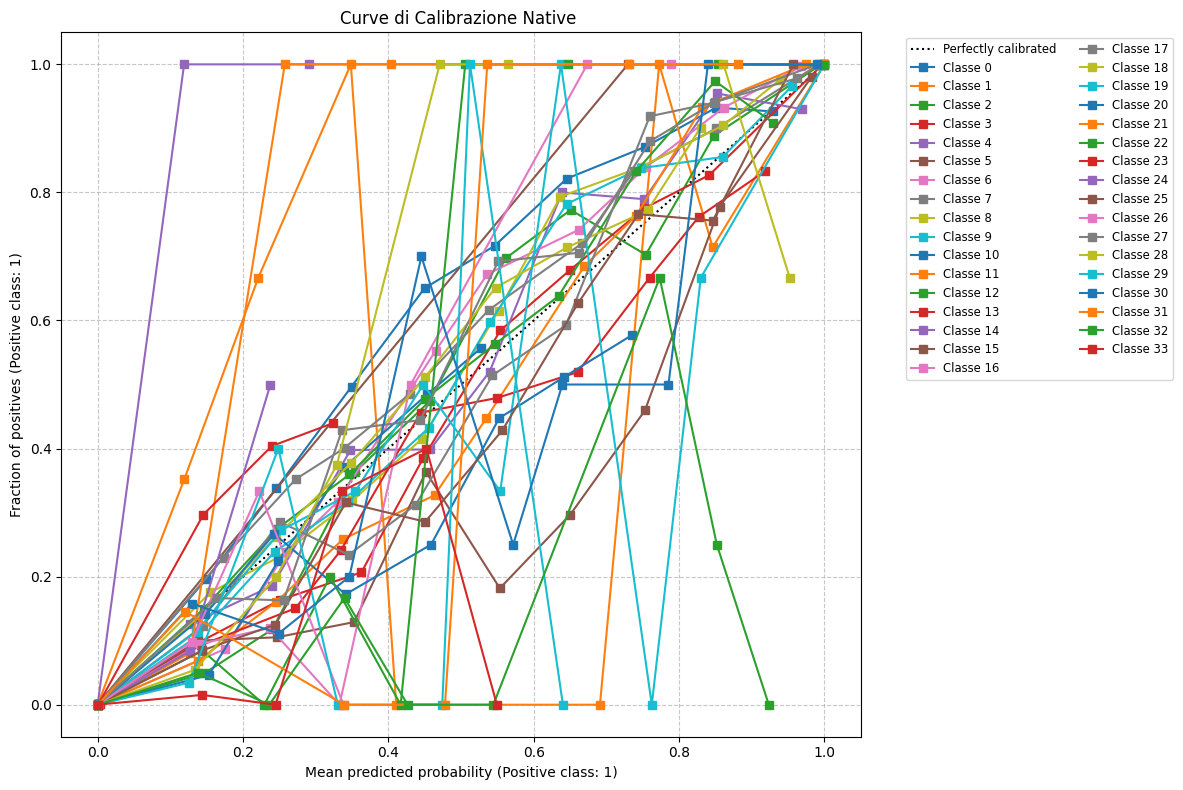


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.74      0.84      0.79      3422
           1       1.00      1.00      1.00     12769
           2       0.98      0.98      0.98      2307
           3       0.85      0.40      0.54     10293
           4       0.62      0.35      0.45       565
           5       1.00      1.00      1.00     22325
           6       0.80      0.45      0.57     13950
           7       0.50      0.38      0.43     12628
           8       0.72      0.95      0.82     16801
           9       0.67      0.62      0.65       959
          10       0.49      0.52      0.50     11207
          11       0.47      0.81      0.59      8312
          12       0.46      0.66      0.54      1182
          13       0.37      0.50      0.43      6285
          14       1.00      1.00      1.00     12558
          15       0.56      0.95      0.71       177
          16       0.96      0.99      0.97      1401
    

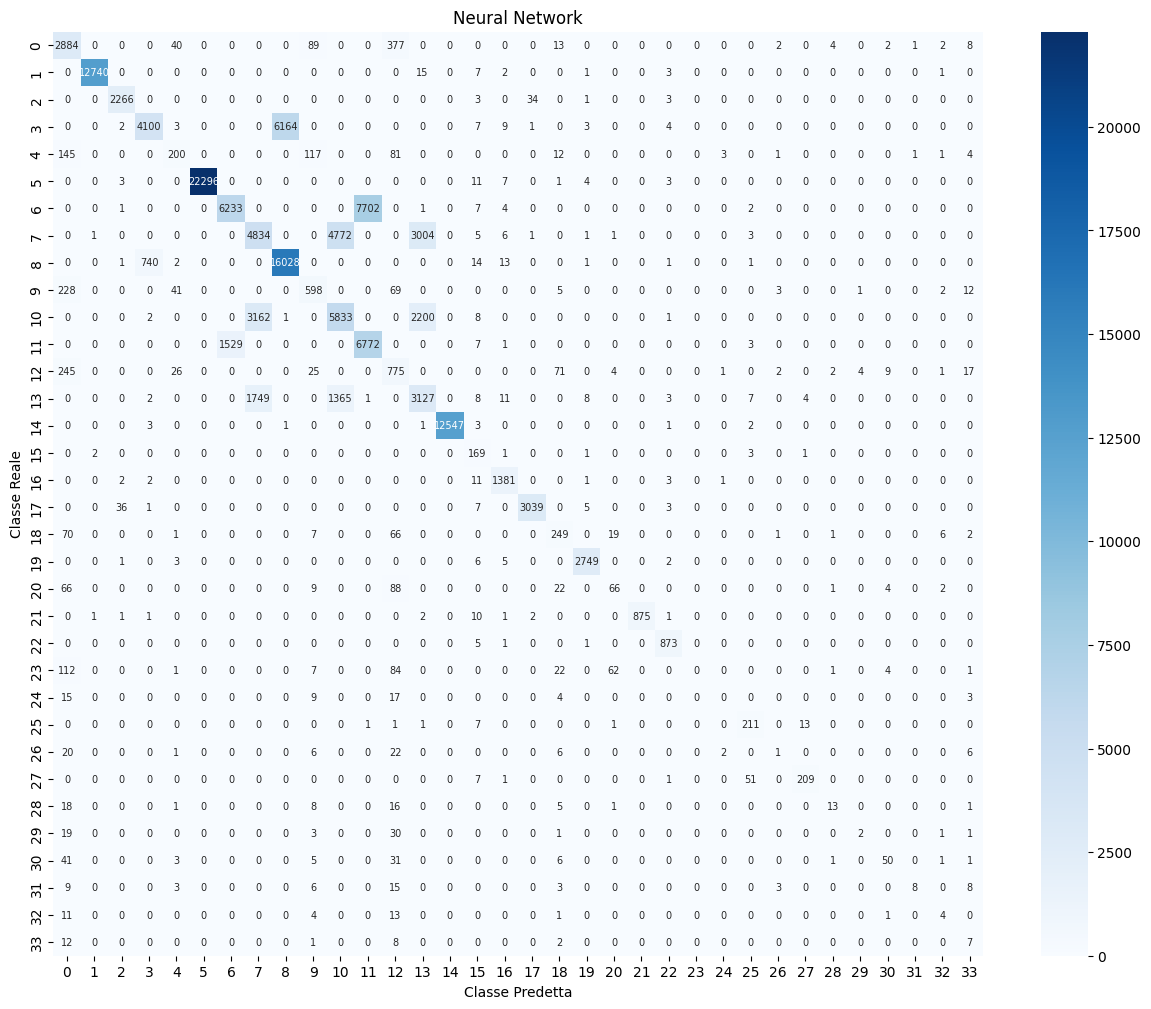

In [ ]:

# Rete Neurale
from sklearn.preprocessing import StandardScaler   

import tensorflow as tf
from tensorflow import keras
from keras import optimizers, layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split (X_temp,y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# -- Oversampling e Undersampling -- 
MAX_RIGHE = 15000
MIN_RIGHE = 1000
conteggi = Counter(y_train)

# non essendoci più il CalibratedClassifierCV non è necessario fare le funzioni che calcolano in. "tempo reale" ma sono sufficienti dizionari statici 
under_dict = {clas: min(n, MAX_RIGHE) for clas, n in conteggi.items()}
over_dict  = {clas: max(under_dict[clas], MIN_RIGHE) for clas, n in conteggi.items()}

undersampler = RandomUnderSampler(sampling_strategy=under_dict, random_state=42)
oversampler  = SMOTE(sampling_strategy=over_dict, random_state=42, k_neighbors=3)

X_train_res, y_train_res = undersampler.fit_resample(X_train, y_train)
X_train_res, y_train_res = oversampler.fit_resample(X_train_res, y_train_res)

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

num_classes = 34

model = keras.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),                    # Spegne il 20% dei neuroni, previene l'overfitting
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"), 
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#Applico un early stop anche in questo modello per evitare di sprecare tempo prezioso 
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

#weight = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
#diz_weight = dict(enumerate(weight))            #Le reti neurali necessitano di un dizionario per i pesi

history = model.fit(
    X_train_res, y_train_res,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    #class_weight=diz_weight,            
    verbose=1,
    callbacks=[early_stop]
)

y_pred_probs = model.predict(X_test)        # invece di restituire un valore unico la rete neurale restituisce la probabilità per ogni classe 
y_pred_rn = np.argmax(y_pred_probs, axis=1) # Prende la probabilità più alta

accuracy_rn = accuracy_score(y_test, y_pred_rn)
precision_rn = precision_score(y_test, y_pred_rn, average='weighted', zero_division=0)
recall_rn = recall_score(y_test, y_pred_rn, average='weighted')
f1_rn = f1_score(y_test, y_pred_rn, average='weighted')
f1_rn_macro   = f1_score(y_test, y_pred_rn, average='macro', zero_division=0) 


print(f"Accuracy: {accuracy_rn:.2f}")
print(f"Precision: {precision_rn:.2f}")
print(f"Recall: {recall_rn:.2f}")
print(f"F1-Score: {f1_rn:.2f}")
print(f"F1 MACRO:  {f1_rn_macro:.2f}")

# -- GRAFICO --

plt.figure(figsize=(12, 8))
asse_grafico = plt.gca()

for classe in range(34):
    y_binario = (y_test == classe).astype(int)
    prob_classe = y_pred_probs[:, classe] # Prendiamo le probabilità native del Softmax
    
    CalibrationDisplay.from_predictions(
        y_binario,                   
        prob_classe,               
        n_bins=10,                        
        name=f"Classe {classe}",          
        ax=asse_grafico                   
    )
    
plt.title("Curve di Calibrazione Native ")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.tight_layout() 
plt.show()

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_rn, zero_division=0))

print("\nCONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred_rn)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True,fmt='g', annot_kws={"size":7}, cmap='Blues',cbar=True)
plt.title('Neural Network')
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.show()

#TEST
# Test con train/test/val di 70%15%15% e n_neuroni = 64 Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.74 T_esec: 4:46 
# Test con train/test/val di 80%10%10% e n_neuroni = 64 Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.74 T_esec: 2:43
# Test con train/test/val di 80%10%10% e n_neuroni = 256 Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77, F1-Score: 0.77 T_esec: 6:49 -- Aumento i numero da 64 a 256 e il dropuot da 0.2 a 0.3. Noto che l'accuratezza è rimasta uguale ma F1 è aumentato quindi le statistiche sono migliorate, a discapito dei tempi
# Test con train/test/val di 80%10%10% e n_neuroni = 256 batch_size 256 learning_rate 1e-3 Risultati: Accuracy: 0.77, Precision: 0.78, Recall: 0.77 F1-Score: 0.76 T_esec: 2:52  -- Rimuovo i pesi e alzo il learning rate testando solo con un aumento del batch_size. 

#OSSERVAZIONI
# Assegnare un peso alle classi per questo modello non si è rivelato un passagio utile.
# Anche con questo modello i risultati non superano il 77% di accuratezza ma si nota un aumnto per quanto riguarda F1_score e la netta riduzione dei tempi.

#TEST 2
# Applico un straficazione nello split (stratify=y) per bilanciare ancora di più li split di addestramento e test.
# Risultati: Accuracy: 0.77 Precision: 0.78 Recall: 0.77 F1-Score: 0.75 T_esec: 5:15 -- Rimuovo

#Applico un nuovo layer aumentando i neuroni da 256 a 512, Risultati: non sufficienti

#Test 3
# Aggiunto Oversampling e Undersampling Risultati: Accuracy: 0.75 Precision: 0.79 Recall: 0.75 F1-Score: 0.74 T_esec:2:38 (MAX_RIGHE = 15000, MIN_RIGHE = 3000)
# Applicando Oversampling e Undersampling l'accuratezza è peggiorata, questo perchè la rete neurale è costretta ad imparare anche le classi minori che prima evitava.

# Dopo ver riaggiunto tre colonne: Header Lenght, psh_flag_number e rst_flag_number Risultati: Accuracy: 0.75 Precision: 0.78 Recall: 0.75 F1-Score: 0.75 macro avg: 0.58 T_esec: 4:07


Epoch 1/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6207 - loss: 0.9359 - val_accuracy: 0.7017 - val_loss: 0.5455 - learning_rate: 0.0010
Epoch 2/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6613 - loss: 0.7618 - val_accuracy: 0.7269 - val_loss: 0.5196 - learning_rate: 0.0010
Epoch 3/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6705 - loss: 0.7391 - val_accuracy: 0.7156 - val_loss: 0.5177 - learning_rate: 0.0010
Epoch 4/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6770 - loss: 0.7255 - val_accuracy: 0.7273 - val_loss: 0.5070 - learning_rate: 0.0010
Epoch 5/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6835 - loss: 0.7166 - val_accuracy: 0.7063 - val_loss: 0.5173 - learning_rate: 0.0010
Epoch 6/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6877 - loss: 0.7089 - val_accuracy: 0.7216 - val_loss: 0.5033 - learning_rate: 0.0010
Epoch 7/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6

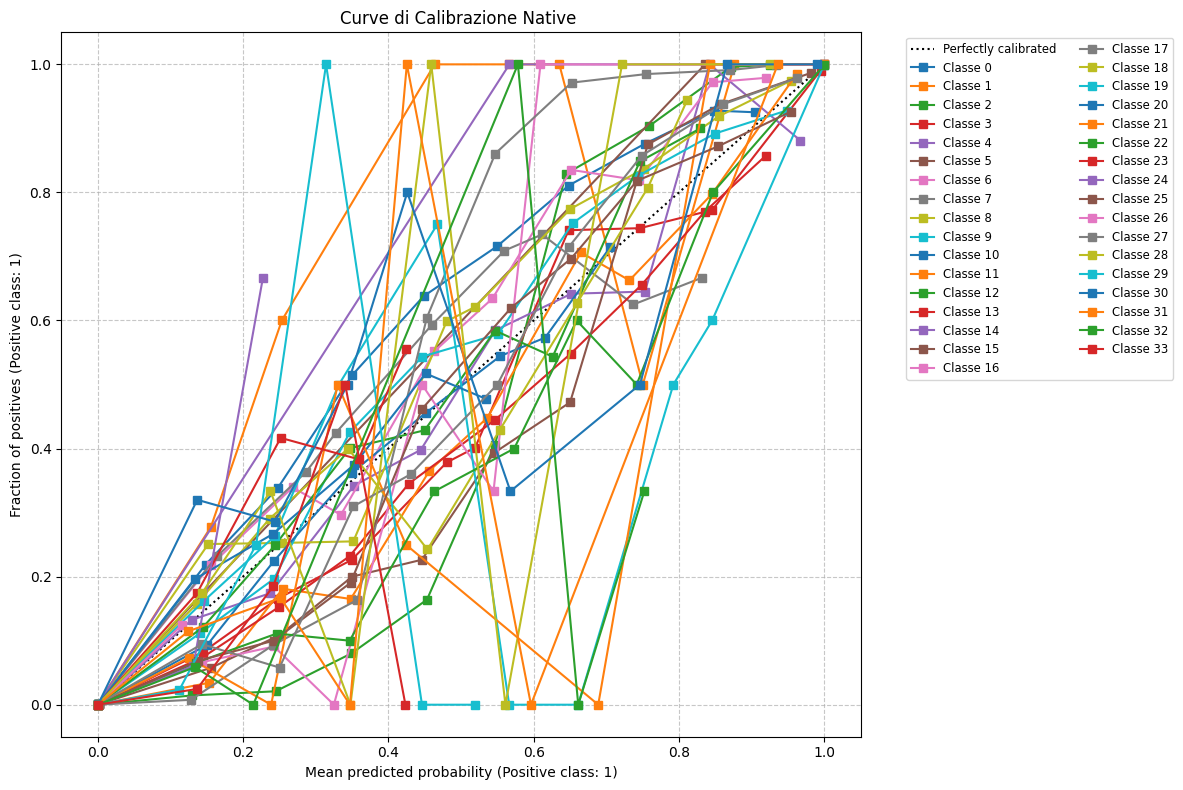


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.72      0.84      0.78      3422
           1       1.00      1.00      1.00     12769
           2       0.95      0.98      0.97      2307
           3       0.57      0.63      0.60     10293
           4       0.61      0.35      0.44       565
           5       1.00      1.00      1.00     22325
           6       0.77      0.49      0.60     13950
           7       0.62      0.12      0.21     12628
           8       0.76      0.71      0.74     16801
           9       0.68      0.58      0.63       959
          10       0.45      0.75      0.56     11207
          11       0.47      0.75      0.58      8312
          12       0.43      0.69      0.53      1182
          13       0.33      0.46      0.38      6285
          14       1.00      1.00      1.00     12558
          15       0.49      0.95      0.65       177
          16       0.97      0.99      0.98      1401
    

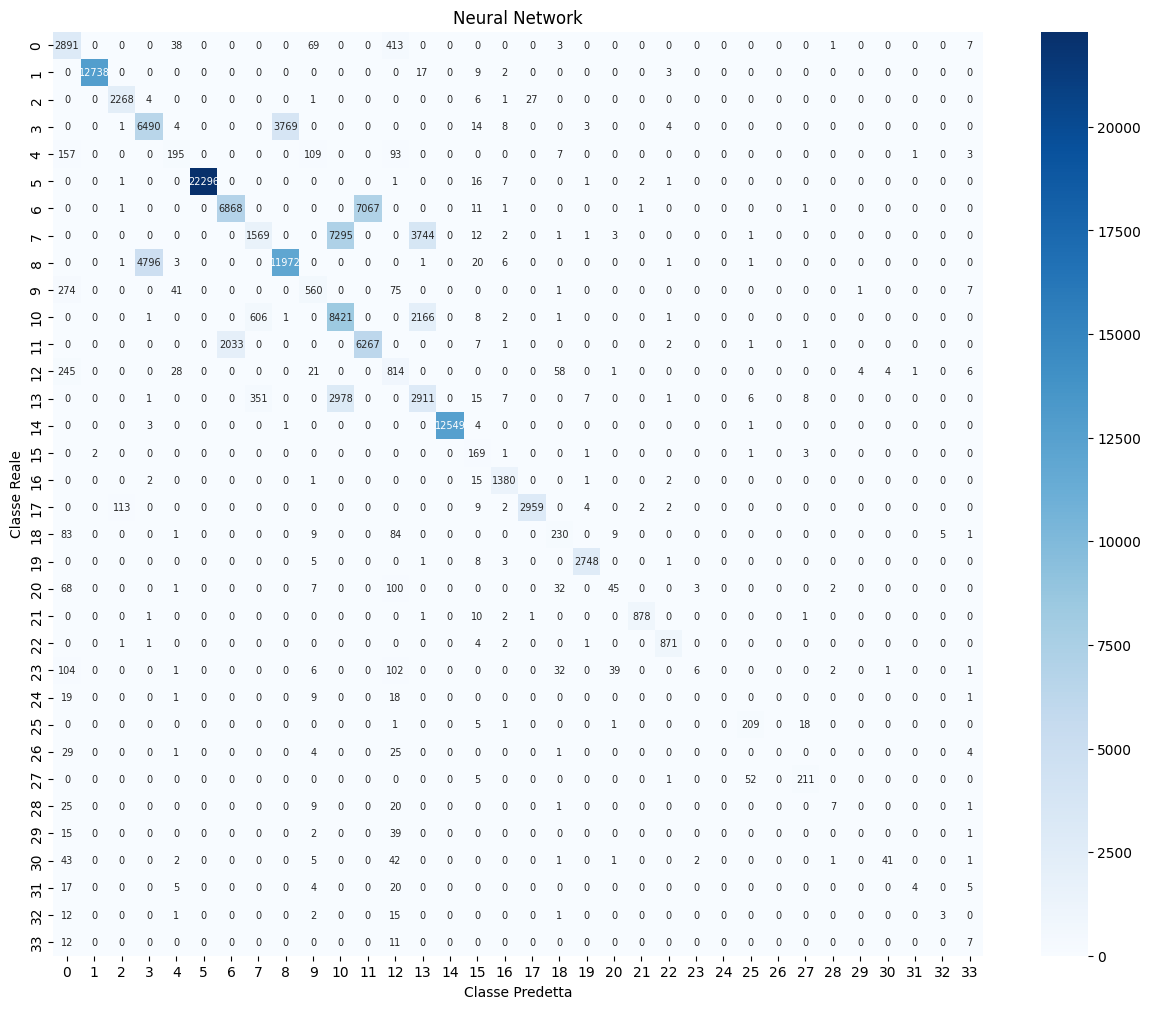

In [ ]:
#RNN
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from keras import optimizers, layers

X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split (X_temp,y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# -- Oversampling e Undersampling -- 
MAX_RIGHE = 15000
MIN_RIGHE = 1000
conteggi = Counter(y_train)

# non essendoci più il CalibratedClassifierCV non è necessario fare le funzioni che calcolano in. "tempo reale" ma sono sufficienti dizionari statici 
under_dict = {clas: min(n, MAX_RIGHE) for clas, n in conteggi.items()}
over_dict  = {clas: max(under_dict[clas], MIN_RIGHE) for clas, n in conteggi.items()}

undersampler = RandomUnderSampler(sampling_strategy=under_dict, random_state=42)
oversampler  = SMOTE(sampling_strategy=over_dict, random_state=42, k_neighbors=3)

X_train_res, y_train_res = undersampler.fit_resample(X_train, y_train)
X_train_res, y_train_res = oversampler.fit_resample(X_train_res, y_train_res)

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

num_classes = 34

# -- RESHAPE 3D --
X_train_rnn = np.reshape(X_train_res, (X_train_res.shape[0], 1, X_train_res.shape[1]))          #trasformo i dati da (RIGA,COLONNA) a (RIGA,1,COLONNA) in modo che abbiano 3 dimensioni
X_val_rnn   = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
X_test_rnn  = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

#PESI
weights=compute_class_weight('balanced',classes=np.unique(y_train_res),y=y_train_res)
diz_weight = dict(enumerate(weights))


model_rnn = keras.Sequential([
    layers.InputLayer(shape=(1, X_train_res.shape[1])),
    layers.SimpleRNN(128,return_sequences=False,activation='tanh'), 
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model_rnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # dimezza il learning rate
    patience=4,       # dopo 4 epoch senza miglioramento
    min_lr=1e-6,      # non scende sotto questo valore
    verbose=1
)

history_rnn = model_rnn.fit(
    X_train_rnn, y_train_res,
    validation_data=(X_val_rnn, y_val),
    epochs=100,
    batch_size=256,
    #class_weight=diz_weight,
    verbose=1,
    callbacks=[early_stop, reduce_lr]
)

#--METRICHE--
y_pred_probs_rnn = model_rnn.predict(X_test_rnn)
y_pred_rnn       = np.argmax(y_pred_probs_rnn, axis=1)

accuracy_rnn   = accuracy_score(y_test, y_pred_rnn)
precision_rnn  = precision_score(y_test, y_pred_rnn, average='weighted', zero_division=0)
recall_rnn     = recall_score(y_test, y_pred_rnn, average='weighted', zero_division=0)
f1_rnn_w       = f1_score(y_test, y_pred_rnn, average='weighted', zero_division=0)
f1_rnn_macro   = f1_score(y_test, y_pred_rnn, average='macro', zero_division=0) 

print(f"Accuracy: {accuracy_rn:.2f}")
print(f"Precision: {precision_rn:.2f}")
print(f"Recall: {recall_rn:.2f}")
print(f"F1-Score: {f1_rn:.2f}")
print(f"F1 MACRO: {f1_rnn_macro:.2f}")

# -- GRAFICI --

plt.figure(figsize=(12, 8))
asse_grafico = plt.gca()

for classe in range(num_classes):
    y_binario = (y_test == classe).astype(int)
    prob_classe = y_pred_probs_rnn[:, classe]
    
    CalibrationDisplay.from_predictions(
        y_binario,                   
        prob_classe,               
        n_bins=10,                        
        name=f"Classe {classe}",          
        ax=asse_grafico                   
    )
    
plt.title("Curve di Calibrazione Native ")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
plt.tight_layout() 
plt.show()

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_rnn, zero_division=0))

print("\nCONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred_rnn)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True,fmt='g', annot_kws={"size":7}, cmap='Blues',cbar=True)
plt.title('Neural Network')
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.show()

#Test
# RNN Con smote, pesi e reduce_lr, Risultati: Accuracy: 0.76 Precision: 0.78 Recall: 0.76 F1-Score: 0.75 F1 MACRO: 0.54 T_esec:2:57 -- Come da previsioni i risultati sono peggiori di altri modelli
# RNN Con smote e reduce_lr, Risultati: Accuracy: 0.76 Precision: 0.78 Recall: 0.76 F1-Score: 0.75 F1 MACRO: 0.56 T_esec:1:11 -- Il macro é leggermente meglio ma penso sia un caso
